# CH1. 소나무재선충병 발생현황 EDA

## 기준
- 단위: 등록 대상목 행(row)
- 핵심 지표: `감염목구분 == "감염목"`
- 지역: `법정동코드` 앞 5자리 시군구
- 날짜: `조사일자`
- 주의: `감염목비율`은 감염률이 아니라 등록자료 내 구성비


### 1. 데이터 로드


In [24]:
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902")
csv_files = sorted(DATA_DIR.glob("병해충발생정보관리_*.csv"))

csv_files

[WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2016.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2017.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2018.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2019.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2020.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2021.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2022.csv'),
 WindowsPath('../data/CH1/산림청_산림병해충방제 병해충발생관리정보_20250902/병해충발생정보관리_2023.csv')]

In [25]:
file_info = pd.DataFrame({
    "file": [p.name for p in csv_files],
    "size_mb": [round(p.stat().st_size / 1024 / 1024, 1) for p in csv_files],
})
file_info

,file,size_mb
0,병해충발생정보관리_2016.csv,128.3
1,병해충발생정보관리_2017.csv,228.6
2,병해충발생정보관리_2018.csv,210.6
3,병해충발생정보관리_2019.csv,172.9
4,병해충발생정보관리_2020.csv,124.4
5,병해충발생정보관리_2021.csv,101.0
6,병해충발생정보관리_2022.csv,102.5
7,병해충발생정보관리_2023.csv,47.1


In [26]:
sample = pd.read_csv(csv_files[0], encoding="cp949", nrows=5, dtype=str)
sample

,발생관리기관코드,지역X좌표,지역Y좌표,국가지점번호,PNU코드,법정동코드,발생경급수치,고사목구분,감염목구분,조사일자,방제완료여부
0,5420000,324004,274227,라라78357385,4882040021111080000,4882040021,38,피해고사목,감염목,2016-01-05,완료
1,5420000,324014,274232,라라78367385,4882040021111080000,4882040021,36,피해고사목,감염목,2016-01-05,완료
2,5420000,324051,274272,라라78407389,4882040021112580005,4882040021,30,피해고사목,감염목,2016-01-05,완료
3,5420000,323980,274182,라라78337380,4882040021113270000,4882040021,28,피해고사목,감염목,2016-01-05,완료
4,5420000,323994,274182,라라78347380,4882040021112560000,4882040021,36,피해고사목,감염목,2016-01-05,완료


### 2. 기본 집계 테이블


In [27]:
usecols = [
    "발생관리기관코드",
    "지역X좌표",
    "지역Y좌표",
    "국가지점번호",
    "PNU코드",
    "법정동코드",
    "발생경급수치",
    "고사목구분",
    "감염목구분",
    "조사일자",
    "방제완료여부",
]

dtype = {
    "발생관리기관코드": "string",
    "지역X좌표": "string",
    "지역Y좌표": "string",
    "국가지점번호": "string",
    "PNU코드": "string",
    "법정동코드": "string",
    "발생경급수치": "string",
    "고사목구분": "string",
    "감염목구분": "string",
    "조사일자": "string",
    "방제완료여부": "string",
}

chunksize = 300_000

file_summary = []
yearly_parts = []
monthly_parts = []
sido_parts = []
sgg_parts = []
dead_infect_parts = []
quality_parts = []

pnu_counter = Counter()
grid_counter = Counter()

for path in csv_files:
    print(f"processing: {path.name}")
    
    for chunk in pd.read_csv(
        path,
        encoding="cp949",
        usecols=usecols,
        dtype=dtype,
        chunksize=chunksize,
    ):
        chunk["조사일자"] = pd.to_datetime(chunk["조사일자"], errors="coerce")
        chunk["발생연도"] = chunk["조사일자"].dt.year
        chunk["발생월"] = chunk["조사일자"].dt.month
        chunk["발생분기"] = chunk["조사일자"].dt.quarter
        
        chunk["법정동코드"] = chunk["법정동코드"].str.strip()
        chunk["시도코드"] = chunk["법정동코드"].str[:2]
        chunk["시군구코드"] = chunk["법정동코드"].str[:5]
        
        chunk["감염목여부"] = chunk["감염목구분"].eq("감염목")
        chunk["피해고사목여부"] = chunk["고사목구분"].eq("피해고사목")
        chunk["발생경급수치"] = pd.to_numeric(chunk["발생경급수치"], errors="coerce")
        
        total_rows = len(chunk)
        
        file_summary.append({
            "파일명": path.name,
            "행수": total_rows,
            "최소조사일자": chunk["조사일자"].min(),
            "최대조사일자": chunk["조사일자"].max(),
            "감염목수": chunk["감염목여부"].sum(),
            "미감염수": total_rows - chunk["감염목여부"].sum(),
        })
        
        quality_parts.append(pd.DataFrame({
            "파일명": path.name,
            "컬럼": usecols,
            "결측수": [chunk[col].isna().sum() + chunk[col].eq("").sum() if chunk[col].dtype == "string" else chunk[col].isna().sum() for col in usecols]
        }))
        
        yearly_parts.append(
            chunk.groupby("발생연도", dropna=False)
            .agg(
                전체건수=("감염목여부", "size"),
                감염목수=("감염목여부", "sum"),
                피해고사목수=("피해고사목여부", "sum"),
                평균경급=("발생경급수치", "mean"),
            )
            .reset_index()
        )
        
        monthly_parts.append(
            chunk.groupby(["발생연도", "발생월"], dropna=False)
            .agg(
                전체건수=("감염목여부", "size"),
                감염목수=("감염목여부", "sum"),
                피해고사목수=("피해고사목여부", "sum"),
            )
            .reset_index()
        )
        
        sido_parts.append(
            chunk.groupby(["발생연도", "시도코드"], dropna=False)
            .agg(
                전체건수=("감염목여부", "size"),
                감염목수=("감염목여부", "sum"),
                피해고사목수=("피해고사목여부", "sum"),
            )
            .reset_index()
        )
        
        sgg_parts.append(
            chunk.groupby(["발생연도", "시군구코드"], dropna=False)
            .agg(
                전체건수=("감염목여부", "size"),
                감염목수=("감염목여부", "sum"),
                피해고사목수=("피해고사목여부", "sum"),
                평균경급=("발생경급수치", "mean"),
            )
            .reset_index()
        )
        
        dead_infect_parts.append(
            chunk.groupby(["고사목구분", "감염목구분"], dropna=False)
            .size()
            .reset_index(name="건수")
        )
        
        infected = chunk[chunk["감염목여부"]]
        pnu_counter.update(infected["PNU코드"].dropna().astype(str))
        grid_counter.update(infected["국가지점번호"].dropna().astype(str))

processing: 병해충발생정보관리_2016.csv
processing: 병해충발생정보관리_2017.csv
processing: 병해충발생정보관리_2018.csv
processing: 병해충발생정보관리_2019.csv
processing: 병해충발생정보관리_2020.csv
processing: 병해충발생정보관리_2021.csv
processing: 병해충발생정보관리_2022.csv
processing: 병해충발생정보관리_2023.csv


In [28]:
file_summary_df = (
    pd.DataFrame(file_summary)
    .groupby("파일명", as_index=False)
    .agg(
        행수=("행수", "sum"),
        최소조사일자=("최소조사일자", "min"),
        최대조사일자=("최대조사일자", "max"),
        감염목수=("감염목수", "sum"),
        미감염수=("미감염수", "sum"),
    )
)

file_summary_df["감염목비율"] = file_summary_df["감염목수"] / file_summary_df["행수"]

yearly = (
    pd.concat(yearly_parts)
    .groupby("발생연도", as_index=False)
    .agg(
        전체건수=("전체건수", "sum"),
        감염목수=("감염목수", "sum"),
        피해고사목수=("피해고사목수", "sum"),
        평균경급=("평균경급", "mean"),
    )
    .sort_values("발생연도")
)

yearly["감염목비율"] = yearly["감염목수"] / yearly["전체건수"]
yearly["전년대비증감률"] = yearly["감염목수"].pct_change() * 100

monthly = (
    pd.concat(monthly_parts)
    .groupby(["발생연도", "발생월"], as_index=False)
    .sum()
    .sort_values(["발생연도", "발생월"])
)

sido_year = (
    pd.concat(sido_parts)
    .groupby(["발생연도", "시도코드"], as_index=False)
    .sum()
)

sgg_year = (
    pd.concat(sgg_parts)
    .groupby(["발생연도", "시군구코드"], as_index=False)
    .agg(
        전체건수=("전체건수", "sum"),
        감염목수=("감염목수", "sum"),
        피해고사목수=("피해고사목수", "sum"),
        평균경급=("평균경급", "mean"),
    )
)

sgg_year["감염목비율"] = sgg_year["감염목수"] / sgg_year["전체건수"]

dead_infect = (
    pd.concat(dead_infect_parts)
    .groupby(["고사목구분", "감염목구분"], as_index=False)
    .sum()
)

quality = (
    pd.concat(quality_parts)
    .groupby(["파일명", "컬럼"], as_index=False)["결측수"]
    .sum()
)

file_summary_df

,파일명,행수,최소조사일자,최대조사일자,감염목수,미감염수,감염목비율
0,병해충발생정보관리_2016.csv,1260952,2016-01-05,2016-12-31,507514,753438,0.402485
1,병해충발생정보관리_2017.csv,2146276,2017-01-01,2017-12-31,659146,1487130,0.307111
2,병해충발생정보관리_2018.csv,1907700,2018-01-01,2018-12-31,486431,1421269,0.254983
3,병해충발생정보관리_2019.csv,1565075,2019-01-01,2019-12-31,388949,1176126,0.248518
4,병해충발생정보관리_2020.csv,1125739,2020-01-01,2020-12-31,304734,821005,0.270697
5,병해충발생정보관리_2021.csv,914593,2021-01-01,2021-12-31,298569,616024,0.326450
6,병해충발생정보관리_2022.csv,927709,2022-01-01,2022-12-31,377401,550308,0.406810
7,병해충발생정보관리_2023.csv,426279,2023-01-01,2023-04-30,163522,262757,0.383603


### 보조. 달력연도별 등록 현황

- 원천자료 구조 확인용
- 최종 해석은 관리주기 기준 사용


In [29]:
yearly

,발생연도,전체건수,감염목수,피해고사목수,평균경급,감염목비율,전년대비증감률
0,2016,1260952,507514,637334,19.425208,0.402485,<NA>
1,2017,2146276,659146,793200,19.195345,0.307111,29.877402
2,2018,1907700,486431,555554,19.250835,0.254983,-26.202844
3,2019,1565075,388949,439092,20.393115,0.248518,-20.040252
4,2020,1125739,304734,334387,22.239147,0.270697,-21.651939
5,2021,914593,298569,320329,24.824192,0.32645,-2.023076
6,2022,927709,377401,435352,24.652911,0.40681,26.403277
7,2023,426279,163522,224373,23.368715,0.383603,-56.671551


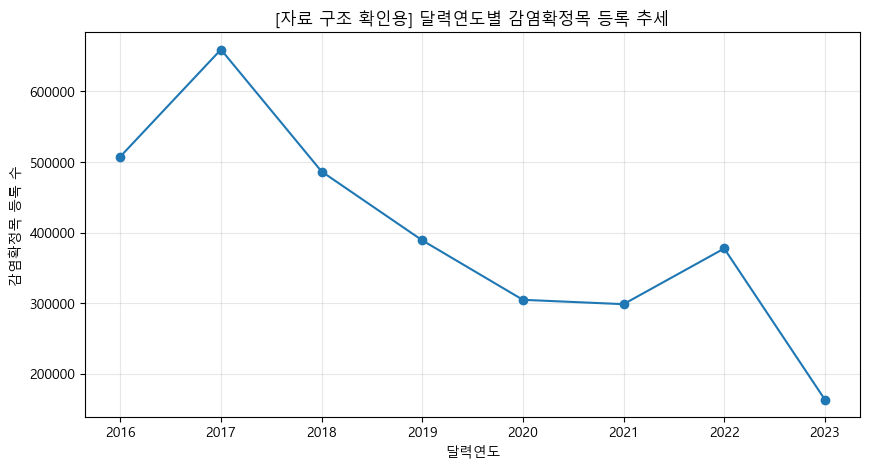

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(yearly["발생연도"], yearly["감염목수"], marker="o")
plt.title("[자료 구조 확인용] 달력연도별 감염확정목 등록 추세")
plt.xlabel("달력연도")
plt.ylabel("감염확정목 등록 수")
plt.grid(alpha=0.3)
plt.show()

### 보조. 달력월별 등록 분포

- 조사/등록월 분포 확인용
- 발생월로 해석하지 않음


In [31]:
monthly_pivot = monthly.pivot_table(
    index="발생월",
    columns="발생연도",
    values="감염목수",
    aggfunc="sum"
)

monthly_pivot

발생연도,2016,2017,2018,2019,2020,2021,2022,2023
발생월,,,,,,,,
1,53,71496,67705,84402,63716,49843,57638,65612
2,84,74526,90982,43279,51880,27415,30106,36748
3,8,49624,51662,28709,14155,30949,40184,39831
4,139,12321,17594,3010,4479,1602,30455,21331
5,6721,931,191,1447,7564,628,7943,<NA>
6,5366,173,898,998,106,584,2029,<NA>
7,8574,139,1687,675,144,1596,2617,<NA>
8,5965,426,1393,335,64,1281,4487,<NA>
9,17894,35418,12513,11472,2990,5177,10607,<NA>


In [32]:
monthly_pivot = monthly.pivot_table(
    index="발생월",
    columns="발생연도",
    values="감염목수",
    aggfunc="sum"
)

monthly_pivot

발생연도,2016,2017,2018,2019,2020,2021,2022,2023
발생월,,,,,,,,
1,53,71496,67705,84402,63716,49843,57638,65612
2,84,74526,90982,43279,51880,27415,30106,36748
3,8,49624,51662,28709,14155,30949,40184,39831
4,139,12321,17594,3010,4479,1602,30455,21331
5,6721,931,191,1447,7564,628,7943,<NA>
6,5366,173,898,998,106,584,2029,<NA>
7,8574,139,1687,675,144,1596,2617,<NA>
8,5965,426,1393,335,64,1281,4487,<NA>
9,17894,35418,12513,11472,2990,5177,10607,<NA>


### 3. 시군구별 등록 현황


In [33]:
from pathlib import Path

bjd_path = Path("../data/CH1/법정동코드 전체자료/법정동코드 전체자료.txt")

bjd = pd.read_csv(
    bjd_path,
    sep="\t",
    encoding="cp949",
    dtype={"법정동코드": "string"}
)

bjd["법정동코드"] = bjd["법정동코드"].str.strip().str.zfill(10)

sgg_codebook = bjd[
    (bjd["법정동코드"].str[5:10] == "00000") &
    (bjd["법정동코드"].str[2:5] != "000")
].copy()

sgg_codebook["시군구코드"] = sgg_codebook["법정동코드"].str[:5]

name_parts = sgg_codebook["법정동명"].str.split(" ", n=1, expand=True)
sgg_codebook["시도명"] = name_parts[0]
sgg_codebook["시군구명"] = name_parts[1].fillna(name_parts[0])
sgg_codebook["행정구역명"] = sgg_codebook["법정동명"]

sgg_codebook = (
    sgg_codebook[["시군구코드", "시도명", "시군구명", "행정구역명", "폐지여부"]]
    .drop_duplicates("시군구코드")
    .sort_values("시군구코드")
    .reset_index(drop=True)
)

sgg_codebook.head()

,시군구코드,시도명,시군구명,행정구역명,폐지여부
0,11110,서울특별시,종로구,서울특별시 종로구,존재
1,11140,서울특별시,중구,서울특별시 중구,존재
2,11170,서울특별시,용산구,서울특별시 용산구,존재
3,11200,서울특별시,성동구,서울특별시 성동구,존재
4,11215,서울특별시,광진구,서울특별시 광진구,존재


In [34]:
sgg_year["시군구코드"] = sgg_year["시군구코드"].astype(str).str.zfill(5)

sgg_year = sgg_year.drop(
    columns=["시도명", "시군구명", "행정구역명", "폐지여부"],
    errors="ignore"
)

sgg_year = sgg_year.merge(
    sgg_codebook,
    on="시군구코드",
    how="left"
)

missing_name = sgg_year["시군구명"].isna().sum()
print("시군구명 미매칭 행 수:", missing_name)

sgg_year[["시군구코드", "시도명", "시군구명", "행정구역명"]].drop_duplicates().head()

시군구명 미매칭 행 수: 2


,시군구코드,시도명,시군구명,행정구역명
0,11140,서울특별시,중구,서울특별시 중구
1,11170,서울특별시,용산구,서울특별시 용산구
2,11260,서울특별시,중랑구,서울특별시 중랑구
3,11290,서울특별시,성북구,서울특별시 성북구
4,26200,부산광역시,영도구,부산광역시 영도구


In [35]:
top_sgg_total = (
    sgg_year
    .groupby(["시도명", "시군구명", "시군구코드"], as_index=False, dropna=False)
    .agg(
        전체건수=("전체건수", "sum"),
        감염목수=("감염목수", "sum"),
        피해고사목수=("피해고사목수", "sum"),
        평균경급=("평균경급", "mean"),
    )
    .sort_values("감염목수", ascending=False)
)

top_sgg_total.head(20)

,시도명,시군구명,시군구코드,전체건수,감염목수,피해고사목수,평균경급
156,제주특별자치도,제주시,50110,658959,400193,386456,19.389766
119,울산광역시,울주군,31710,898332,379109,381542,20.852522
61,경상북도,경주시,47130,660418,305814,305460,23.215459
155,제주특별자치도,서귀포시,50130,330380,202876,202829,24.488788
63,경상북도,구미시,47190,542518,192536,226771,23.760779
43,경상남도,밀양시,48270,434897,180231,127641,21.72601
16,경기도,광주시,41610,212565,143855,139629,20.014897
118,울산광역시,북구,31200,364659,117912,118202,24.337146
81,경상북도,포항시 북구,47113,564150,98558,245990,23.644505
44,경상남도,사천시,48240,155000,90238,56389,24.134879


### 4. 등록 유형 확인


In [36]:
dead_infect

,고사목구분,감염목구분,건수
0,기타고사목,감염목,297261
1,기타고사목,미감염,5948507
2,비병징목,감염목,8595
3,비병징목,미감염,280339
4,피해고사목,감염목,2880410
5,피해고사목,미감염,859211


In [37]:
dead_infect_pivot = dead_infect.pivot_table(
    index="고사목구분",
    columns="감염목구분",
    values="건수",
    aggfunc="sum",
    fill_value=0
)

dead_infect_pivot["합계"] = dead_infect_pivot.sum(axis=1)

if "감염목" in dead_infect_pivot.columns:
    dead_infect_pivot["감염목비율"] = dead_infect_pivot["감염목"] / dead_infect_pivot["합계"]

dead_infect_pivot

감염목구분,감염목,미감염,합계,감염목비율
고사목구분,,,,
기타고사목,297261,5948507,6245768,0.047594
비병징목,8595,280339,288934,0.029747
피해고사목,2880410,859211,3739621,0.770241


### 제외. 행 수 기반 반복 후보

- 같은 PNU/국가지점번호의 감염확정목 행 수 카운트
- 반복·재관측 지표로 사용하지 않음
- 최종 지표는 관리주기 중복 제거 후 계산


In [38]:
# 행 수 기반 반복 후보는 최종 CH1 지표에서 제외한다.
# 관리주기 중복 제거 기반 반복·지속·재관측 지표는 뒤쪽 필수 EDA 섹션을 사용한다.


In [39]:
# 제외: 같은 국가지점번호에 등록된 행 수 상위표는 반복 관측 지표가 아니다.


### 5. 데이터 품질 점검


In [40]:
quality_pivot = quality.pivot_table(
    index="컬럼",
    columns="파일명",
    values="결측수",
    aggfunc="sum",
    fill_value=0
)

quality_pivot

파일명,병해충발생정보관리_2016.csv,병해충발생정보관리_2017.csv,병해충발생정보관리_2018.csv,병해충발생정보관리_2019.csv,병해충발생정보관리_2020.csv,병해충발생정보관리_2021.csv,병해충발생정보관리_2022.csv,병해충발생정보관리_2023.csv
컬럼,,,,,,,,
PNU코드,11,2852,2,0,0,0,107,17
감염목구분,0,0,0,0,0,0,0,0
고사목구분,0,0,0,0,0,0,0,0
국가지점번호,11,2852,0,0,0,0,107,16
발생경급수치,0,0,0,0,0,0,0,0
발생관리기관코드,0,0,0,0,0,0,0,0
방제완료여부,0,0,0,0,0,0,0,0
법정동코드,11,2852,2,0,0,0,261,107
조사일자,0,0,0,0,0,0,0,0


In [41]:
ch1_sgg_year_summary = sgg_year.copy()

ch1_sgg_year_summary = ch1_sgg_year_summary.sort_values(
    ["발생연도", "감염목수"],
    ascending=[True, False]
)

ch1_sgg_year_summary.head(20)

,발생연도,시군구코드,전체건수,감염목수,피해고사목수,평균경급,감염목비율,시도명,시군구명,행정구역명,폐지여부
135,2016,50110,198859,146684,147755,18.519838,0.737628,제주특별자치도,제주시,제주특별자치도 제주시,존재
30,2016,31710,155110,86582,87361,21.255697,0.558197,울산광역시,울주군,울산광역시 울주군,존재
122,2016,48270,54782,52593,31286,19.061954,0.960042,경상남도,밀양시,경상남도 밀양시,존재
93,2016,47130,51870,39880,39921,22.453797,0.768845,경상북도,경주시,경상북도 경주시,존재
136,2016,50130,34175,26854,26429,20.246045,0.785779,제주특별자치도,서귀포시,제주특별자치도 서귀포시,존재
92,2016,47113,25853,21546,21551,21.426729,0.833404,경상북도,포항시 북구,경상북도 포항시 북구,존재
46,2016,41610,33295,18867,18867,20.547884,0.566662,경기도,광주시,경기도 광주시,존재
29,2016,31200,26835,15110,15278,26.699096,0.563071,울산광역시,북구,울산광역시 북구,존재
74,2016,46170,35102,10901,10904,22.579196,0.310552,전라남도,나주시,전라남도 나주시,폐지
123,2016,48310,15719,10636,10631,27.589123,0.676633,경상남도,거제시,경상남도 거제시,존재


In [42]:
ch1_sgg_year_summary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1087 entries, 135 to 1082
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   발생연도    1087 non-null   int32  
 1   시군구코드   1087 non-null   object 
 2   전체건수    1087 non-null   Int64  
 3   감염목수    1087 non-null   Int64  
 4   피해고사목수  1087 non-null   Int64  
 5   평균경급    1087 non-null   Float64
 6   감염목비율   1087 non-null   Float64
 7   시도명     1085 non-null   object 
 8   시군구명    1085 non-null   object 
 9   행정구역명   1085 non-null   object 
 10  폐지여부    1085 non-null   object 
dtypes: Float64(2), Int64(3), int32(1), object(5)
memory usage: 103.0+ KB


## 최종. 관리주기 기준 EDA

- 관리주기: 5월~다음 해 4월
- 범위: 2016.5~2017.4부터 2022.5~2023.4까지
- 제외: 2023.5~2024.4는 미완결
- 월별 값: 조사/등록월 기준


In [43]:
from collections import Counter, defaultdict

MANAGEMENT_START = 2016
MANAGEMENT_END = 2022
VALID_CYCLES = list(range(MANAGEMENT_START, MANAGEMENT_END + 1))

def add_management_cycle(df):
    df = df.copy()
    df["조사일자"] = pd.to_datetime(df["조사일자"], errors="coerce")
    year = df["조사일자"].dt.year
    month = df["조사일자"].dt.month
    df["관리주기"] = np.where(month >= 5, year, year - 1)
    df["관리주기"] = pd.Series(df["관리주기"], index=df.index).astype("Int64")
    df["관리주기명"] = df["관리주기"].astype("string") + ".5~" + (df["관리주기"] + 1).astype("string") + ".4"
    df["조사월"] = month.astype("Int64")
    df["관리월순서"] = ((month - 5) % 12 + 1).astype("Int64")
    return df

duplicate_cols = ["관리주기", "지역X좌표", "지역Y좌표", "PNU코드", "고사목구분", "감염목구분", "조사일자"]

cycle_summary_parts = []
cycle_month_parts = []
cycle_sgg_parts = []
cycle_infect_status_parts = []
cycle_dead_infect_parts = []
quality_cycle_parts = []
infected_grid_cycle_parts = []
coord_counter = Counter()
cycle_coord_counter = defaultdict(Counter)
complete_duplicate_count = 0
same_cycle_coord_count = 0
same_coord_diff_pnu_count = 0
same_pnu_diff_coord_count = 0

for path in csv_files:
    for chunk in pd.read_csv(path, encoding="cp949", usecols=usecols, dtype=dtype, chunksize=chunksize):
        chunk = add_management_cycle(chunk)
        chunk = chunk[chunk["관리주기"].isin(VALID_CYCLES)].copy()
        if chunk.empty:
            continue

        for col in ["감염목구분", "고사목구분", "법정동코드", "PNU코드", "국가지점번호", "지역X좌표", "지역Y좌표"]:
            chunk[col] = chunk[col].astype("string").str.strip()

        chunk["시군구코드"] = chunk["법정동코드"].str.zfill(10).str[:5]
        chunk["감염목여부"] = chunk["감염목구분"].eq("감염목")
        chunk["피해고사목여부"] = chunk["고사목구분"].eq("피해고사목")
        chunk["감염목구분_진단"] = chunk["감염목구분"].fillna("결측").replace("", "결측")
        chunk["고사목구분_진단"] = chunk["고사목구분"].fillna("결측").replace("", "결측")

        cycle_summary_parts.append(
            chunk.groupby(["관리주기", "관리주기명"], dropna=False)
            .agg(
                전체등록대상목수=("감염목여부", "size"),
                피해고사목수=("피해고사목여부", "sum"),
                감염확정목수=("감염목여부", "sum"),
            )
            .reset_index()
        )

        cycle_month_parts.append(
            chunk.groupby(["관리주기", "관리주기명", "관리월순서", "조사월"], dropna=False)
            .agg(
                전체등록대상목수=("감염목여부", "size"),
                피해고사목수=("피해고사목여부", "sum"),
                감염확정목수=("감염목여부", "sum"),
            )
            .reset_index()
        )

        cycle_sgg_parts.append(
            chunk.groupby(["관리주기", "관리주기명", "시군구코드"], dropna=False)
            .agg(
                전체등록대상목수=("감염목여부", "size"),
                피해고사목수=("피해고사목여부", "sum"),
                감염확정목수=("감염목여부", "sum"),
            )
            .reset_index()
        )

        cycle_infect_status_parts.append(
            chunk.groupby(["관리주기", "관리주기명", "감염목구분_진단"], dropna=False)
            .size()
            .reset_index(name="건수")
        )

        cycle_dead_infect_parts.append(
            chunk.groupby(["고사목구분_진단", "감염목구분_진단"], dropna=False)
            .size()
            .reset_index(name="건수")
        )

        infected_grid_cycle_parts.append(
            chunk.loc[
                chunk["감염목여부"] & chunk["국가지점번호"].notna() & chunk["국가지점번호"].ne(""),
                ["관리주기", "관리주기명", "국가지점번호"]
            ].drop_duplicates()
        )

        for cycle, subq in chunk.groupby("관리주기", dropna=False):
            q = pd.DataFrame({
                "관리주기": cycle,
                "항목": [
                    "조사일자 결측",
                    "법정동코드 결측",
                    "지역X좌표 결측",
                    "지역Y좌표 결측",
                    "PNU코드 결측",
                    "국가지점번호 결측",
                    "방제완료여부 결측",
                ],
                "건수": [
                    subq["조사일자"].isna().sum(),
                    subq["법정동코드"].isna().sum() + subq["법정동코드"].eq("").sum(),
                    subq["지역X좌표"].isna().sum() + subq["지역X좌표"].eq("").sum(),
                    subq["지역Y좌표"].isna().sum() + subq["지역Y좌표"].eq("").sum(),
                    subq["PNU코드"].isna().sum() + subq["PNU코드"].eq("").sum(),
                    subq["국가지점번호"].isna().sum() + subq["국가지점번호"].eq("").sum(),
                    subq["방제완료여부"].isna().sum() + subq["방제완료여부"].eq("").sum(),
                ],
            })
            quality_cycle_parts.append(q)

        valid_coord = chunk["지역X좌표"].notna() & chunk["지역Y좌표"].notna() & chunk["지역X좌표"].ne("") & chunk["지역Y좌표"].ne("")
        coord_keys = (chunk.loc[valid_coord, "지역X좌표"] + "|" + chunk.loc[valid_coord, "지역Y좌표"]).astype(str)
        coord_counter.update(coord_keys)
        for cycle, coord_sub in chunk.loc[valid_coord].assign(_coord_key=coord_keys).groupby("관리주기", dropna=False):
            cycle_coord_counter[int(cycle)].update(coord_sub["_coord_key"].astype(str))

        complete_duplicate_count += chunk.duplicated(duplicate_cols, keep=False).sum()
        same_cycle_coord_count += chunk.duplicated(["관리주기", "지역X좌표", "지역Y좌표"], keep=False).sum()
        same_coord_diff_pnu_count += chunk.groupby(["지역X좌표", "지역Y좌표"], dropna=True)["PNU코드"].nunique().gt(1).sum()
        same_pnu_diff_coord_count += chunk.groupby("PNU코드", dropna=True).apply(lambda g: (g[["지역X좌표", "지역Y좌표"]].drop_duplicates().shape[0] > 1)).sum()

cycle_summary = (
    pd.concat(cycle_summary_parts)
    .groupby(["관리주기", "관리주기명"], as_index=False)
    .sum()
    .sort_values("관리주기")
)
for col in ["전체등록대상목수", "피해고사목수", "감염확정목수"]:
    cycle_summary[f"{col}_전주기대비증감률"] = cycle_summary[col].pct_change() * 100

cycle_monthly = (
    pd.concat(cycle_month_parts)
    .groupby(["관리주기", "관리주기명", "관리월순서", "조사월"], as_index=False)
    .sum()
    .sort_values(["관리주기", "관리월순서"])
)

cycle_sgg = (
    pd.concat(cycle_sgg_parts)
    .groupby(["관리주기", "관리주기명", "시군구코드"], as_index=False)
    .sum()
)

cycle_infect_status = (
    pd.concat(cycle_infect_status_parts)
    .groupby(["관리주기", "관리주기명", "감염목구분_진단"], as_index=False)
    .sum()
)

cycle_dead_infect = (
    pd.concat(cycle_dead_infect_parts)
    .groupby(["고사목구분_진단", "감염목구분_진단"], as_index=False)
    .sum()
)

cycle_quality = (
    pd.concat(quality_cycle_parts)
    .groupby(["관리주기", "항목"], as_index=False)
    .sum()
)

infected_grid_cycle = pd.concat(infected_grid_cycle_parts).drop_duplicates()
grid_cycle_count = infected_grid_cycle.groupby("국가지점번호")["관리주기"].nunique()

def max_consecutive_run(cycles):
    cycles = sorted(set(int(c) for c in cycles))
    if not cycles:
        return 0
    best = run = 1
    for prev, cur in zip(cycles, cycles[1:]):
        run = run + 1 if cur == prev + 1 else 1
        best = max(best, run)
    return best

grid_cycle_detail = (
    infected_grid_cycle.groupby("국가지점번호")["관리주기"]
    .agg(lambda s: tuple(sorted(set(int(v) for v in s))))
    .reset_index(name="관측관리주기목록")
)
grid_cycle_detail["관측관리주기수"] = grid_cycle_detail["관측관리주기목록"].str.len()
grid_cycle_detail["최대연속관측관리주기수"] = grid_cycle_detail["관측관리주기목록"].map(max_consecutive_run)
grid_cycle_detail["일시관측격자"] = grid_cycle_detail["관측관리주기수"].eq(1)
grid_cycle_detail["반복관측격자"] = grid_cycle_detail["관측관리주기수"].ge(2)
grid_cycle_detail["지속관측격자"] = grid_cycle_detail["최대연속관측관리주기수"].ge(2)
grid_cycle_detail["재관측격자"] = grid_cycle_detail.apply(
    lambda r: r["관측관리주기수"] >= 2 and r["최대연속관측관리주기수"] < r["관측관리주기수"],
    axis=1,
)
grid_cycle_observation_summary = pd.DataFrame({
    "항목": ["일시 관측격자", "반복 관측격자", "지속 관측격자", "재관측격자", "3개 이상 장기 지속격자"],
    "격자수": [
        grid_cycle_detail["일시관측격자"].sum(),
        grid_cycle_detail["반복관측격자"].sum(),
        grid_cycle_detail["지속관측격자"].sum(),
        grid_cycle_detail["재관측격자"].sum(),
        grid_cycle_detail["최대연속관측관리주기수"].ge(3).sum(),
    ],
})

duplicate_coord_summary = pd.DataFrame({
    "항목": ["좌표 고유개수", "2회 이상 반복 좌표", "5회 이상 반복 좌표", "10회 이상 반복 좌표"],
    "건수": [
        len(coord_counter),
        sum(v >= 2 for v in coord_counter.values()),
        sum(v >= 5 for v in coord_counter.values()),
        sum(v >= 10 for v in coord_counter.values()),
    ],
})

duplicate_coord_cycle_summary = pd.DataFrame([
    {
        "관리주기": cycle,
        "관리주기명": f"{cycle}.5~{cycle + 1}.4",
        "좌표고유개수": len(counter),
        "2회이상반복좌표": sum(v >= 2 for v in counter.values()),
        "5회이상반복좌표": sum(v >= 5 for v in counter.values()),
        "10회이상반복좌표": sum(v >= 10 for v in counter.values()),
    }
    for cycle, counter in sorted(cycle_coord_counter.items())
])

coordinate_quality_summary = pd.DataFrame({
    "유형": [
        "완전 중복 행",
        "동일 관리주기·동일 좌표",
        "동일 좌표 반복 등록",
        "관리주기별 동일 좌표 반복",
        "동일 좌표·다른 PNU",
        "동일 PNU·서로 다른 좌표",
    ],
    "확인 기준": [
        "관리주기·좌표·PNU·고사목구분·감염목구분·조사일자가 모두 동일",
        "같은 관리주기 안에서 같은 좌표가 여러 행 등록",
        "전체 기간 중 같은 좌표가 여러 행 등록",
        "관리주기별 같은 좌표 반복 등록",
        "같은 좌표에 2개 이상 PNU가 연결",
        "같은 PNU에 2개 이상 좌표가 연결",
    ],
    "주의": [
        "중복 입력 가능성 우선 점검",
        "여러 본 등록일 수 있어 중복 오류로 단정하지 않음",
        "여러 본·재관측·좌표 정밀도 이슈가 섞임",
        "특정 관리주기 입력 쏠림 점검용",
        "좌표 정밀도 또는 코드 오류 가능성",
        "PNU 공간 범위 내 여러 개체 가능",
    ],
    "건수": [
        complete_duplicate_count,
        same_cycle_coord_count,
        sum(v >= 2 for v in coord_counter.values()),
        duplicate_coord_cycle_summary["2회이상반복좌표"].sum(),
        same_coord_diff_pnu_count,
        same_pnu_diff_coord_count,
    ],
})

cycle_summary


C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_19632\918363405.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  same_pnu_diff_coord_count += chunk.groupby("PNU코드", dropna=True).apply(lambda g: (g[["지역X좌표", "지역Y좌표"]].drop_duplicates().shape[0] > 1)).sum()
C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_19632\918363405.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  same_pnu_diff_coord_count += chunk.

,관리주기,관리주기명,전체등록대상목수,피해고사목수,감염확정목수,전체등록대상목수_전주기대비증감률,피해고사목수_전주기대비증감률,감염확정목수_전주기대비증감률
0,2016,2016.5~2017.4,2211928,992098,715197,<NA>,<NA>,<NA>
1,2017,2017.5~2018.4,1873647,684088,679122,-15.293491,-31.046328,-5.044065
2,2018,2018.5~2019.4,1894997,490936,417888,1.139489,-28.234964,-38.466432
3,2019,2019.5~2020.4,1441076,406369,363779,-23.953653,-17.225667,-12.948206
4,2020,2020.5~2021.4,996482,307919,280313,-30.85153,-24.22675,-22.94415
5,2021,2021.5~2022.4,920075,380600,347143,-7.667675,23.603935,23.841206
6,2022,2022.5~2023.4,932490,474996,382540,1.349347,24.801892,10.196662


,관리주기,관리주기명,전체등록대상목수,피해고사목수,감염확정목수,전체등록대상목수_전주기대비증감률,피해고사목수_전주기대비증감률,감염확정목수_전주기대비증감률
0,2016,2016.5~2017.4,2211928,992098,715197,<NA>,<NA>,<NA>
1,2017,2017.5~2018.4,1873647,684088,679122,-15.293491,-31.046328,-5.044065
2,2018,2018.5~2019.4,1894997,490936,417888,1.139489,-28.234964,-38.466432
3,2019,2019.5~2020.4,1441076,406369,363779,-23.953653,-17.225667,-12.948206
4,2020,2020.5~2021.4,996482,307919,280313,-30.85153,-24.22675,-22.94415
5,2021,2021.5~2022.4,920075,380600,347143,-7.667675,23.603935,23.841206
6,2022,2022.5~2023.4,932490,474996,382540,1.349347,24.801892,10.196662


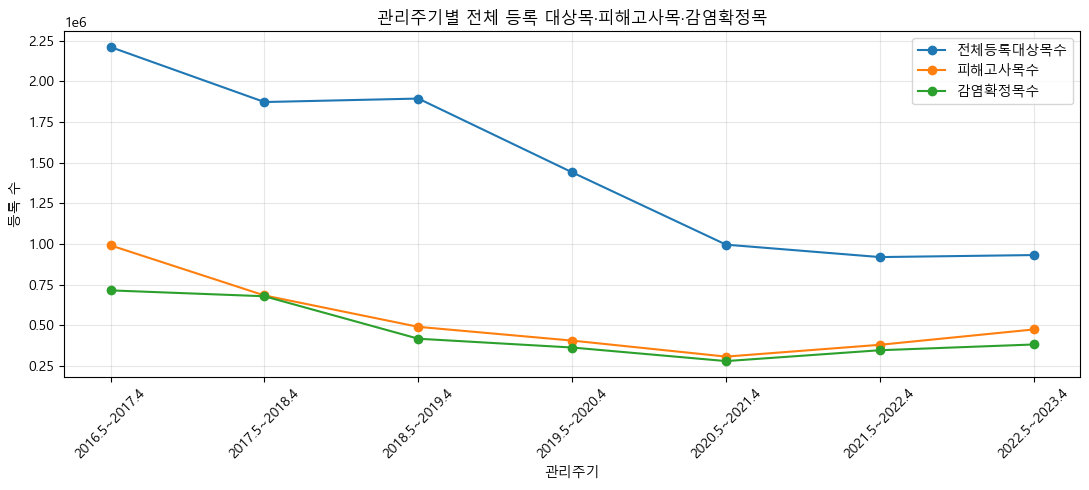

,관리주기,관리주기명,전체등록대상목수,피해고사목수,감염확정목수
0,2016,2016.5~2017.4,100.0,100.0,100.0
1,2017,2017.5~2018.4,84.706509,68.953672,94.955935
2,2018,2018.5~2019.4,85.671731,49.484628,58.429775
3,2019,2019.5~2020.4,65.150222,40.96057,50.864167
4,2020,2020.5~2021.4,45.050381,31.037156,39.193817
5,2021,2021.5~2022.4,41.596065,38.363146,48.538095
6,2022,2022.5~2023.4,42.15734,47.877931,53.487361


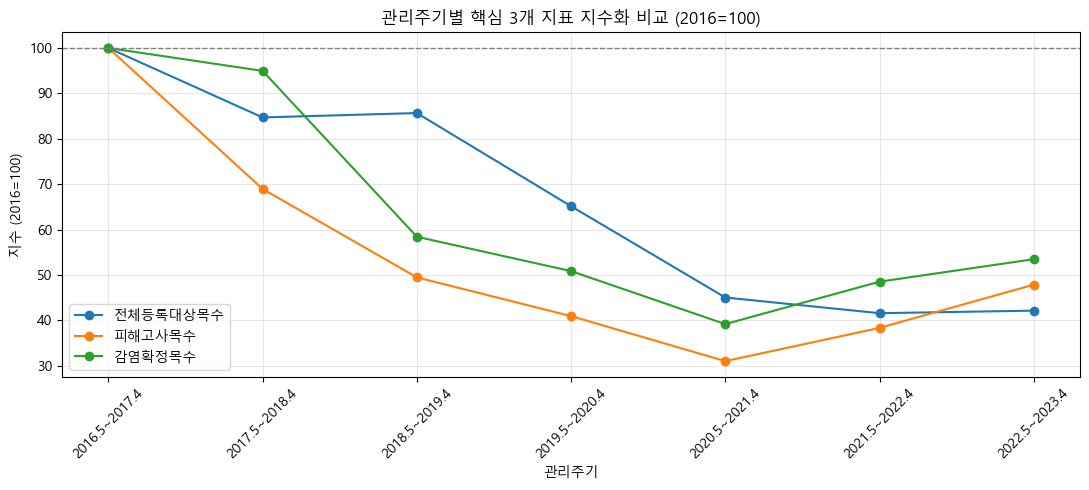

In [44]:
# 1~2. 관리주기별 핵심 3개 지표
display(cycle_summary)

plt.figure(figsize=(11, 5))
for col in ["전체등록대상목수", "피해고사목수", "감염확정목수"]:
    plt.plot(cycle_summary["관리주기명"], cycle_summary[col], marker="o", label=col)
plt.title("관리주기별 전체 등록 대상목·피해고사목·감염확정목")
plt.xlabel("관리주기")
plt.ylabel("등록 수")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 세 지표의 상대 변화 비교: 2016 관리주기=100
index_cols = ["전체등록대상목수", "피해고사목수", "감염확정목수"]
cycle_index_2016 = cycle_summary[["관리주기", "관리주기명"] + index_cols].copy()
base_values = cycle_index_2016.loc[cycle_index_2016["관리주기"] == 2016, index_cols].iloc[0]
cycle_index_2016[index_cols] = cycle_index_2016[index_cols].divide(base_values).multiply(100)
display(cycle_index_2016)

plt.figure(figsize=(11, 5))
for col in index_cols:
    plt.plot(cycle_index_2016["관리주기명"], cycle_index_2016[col], marker="o", label=col)
plt.axhline(100, color="gray", linewidth=1, linestyle="--")
plt.title("관리주기별 핵심 3개 지표 지수화 비교 (2016=100)")
plt.xlabel("관리주기")
plt.ylabel("지수 (2016=100)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
# 3. 고사목구분 × 감염목구분 교차표
dead_infect_required = cycle_dead_infect.pivot_table(
    index="고사목구분_진단",
    columns="감염목구분_진단",
    values="건수",
    aggfunc="sum",
    fill_value=0,
)
dead_infect_required["전체"] = dead_infect_required.sum(axis=1)
display(dead_infect_required)

# 4. 관리주기별 감염목구분 원값 분포
infect_status_pivot = cycle_infect_status.pivot_table(
    index=["관리주기", "관리주기명"],
    columns="감염목구분_진단",
    values="건수",
    aggfunc="sum",
    fill_value=0,
)
infect_status_pivot["전체"] = infect_status_pivot.sum(axis=1)
display(infect_status_pivot)


감염목구분_진단,감염목,미감염,전체
고사목구분_진단,,,
기타고사목,297246,5947533,6244779
비병징목,8595,280315,288910
피해고사목,2880141,856865,3737006


,감염목구분_진단,감염목,미감염,전체
관리주기,관리주기명,,,
2016,2016.5~2017.4,715197,1496731,2211928
2017,2017.5~2018.4,679122,1194525,1873647
2018,2018.5~2019.4,417888,1477109,1894997
2019,2019.5~2020.4,363779,1077297,1441076
2020,2020.5~2021.4,280313,716169,996482
2021,2021.5~2022.4,347143,572932,920075
2022,2022.5~2023.4,382540,549950,932490


In [46]:
# 5. 시군구별 감염확정목 수: 전체기간 상위 지역
cycle_sgg_named = cycle_sgg.merge(sgg_codebook, on="시군구코드", how="left")
missing_sgg_codes = cycle_sgg_named.loc[
    cycle_sgg_named["시군구명"].isna(),
    ["관리주기", "관리주기명", "시군구코드", "전체등록대상목수", "피해고사목수", "감염확정목수"]
].sort_values(["관리주기", "시군구코드"])
display(missing_sgg_codes)

top_sgg_required = (
    cycle_sgg_named[cycle_sgg_named["시군구명"].notna()]
    .groupby(["시도명", "시군구명", "시군구코드"], as_index=False, dropna=False)
    .agg(
        전체등록대상목수=("전체등록대상목수", "sum"),
        피해고사목수=("피해고사목수", "sum"),
        감염확정목수=("감염확정목수", "sum"),
    )
    .sort_values("감염확정목수", ascending=False)
)
display(top_sgg_required.head(20))

# 6. 발생 시군구 수와 분석기간 내 최초 관측 시군구 수
observed_sets = {}
for cycle, sub in cycle_sgg[cycle_sgg["감염확정목수"] > 0].groupby("관리주기"):
    observed_sets[int(cycle)] = set(sub["시군구코드"].dropna().astype(str))

seen_sgg = set()
sgg_spread_rows = []
for cycle in VALID_CYCLES:
    current = observed_sets.get(cycle, set())
    first_observed = current - seen_sgg
    sgg_spread_rows.append({
        "관리주기": cycle,
        "관리주기명": f"{cycle}.5~{cycle + 1}.4",
        "발생시군구수": len(current),
        "분석기간내최초관측시군구수": pd.NA if cycle == VALID_CYCLES[0] else len(first_observed),
        "기준관리주기관측지역수": len(current) if cycle == VALID_CYCLES[0] else pd.NA,
        "누적발생시군구수": len(seen_sgg | current),
    })
    seen_sgg |= current
sgg_spread = pd.DataFrame(sgg_spread_rows)
display(sgg_spread)

# 6-1. 관리주기 중복 제거 기반 반복·지속·재관측 격자 요약
display(grid_cycle_observation_summary)
display(grid_cycle_detail.sort_values(["관측관리주기수", "최대연속관측관리주기수"], ascending=False).head(20))

# 7. 관리주기 내 월별 조사/등록 분포
monthly_required = cycle_monthly.pivot_table(
    index="조사월",
    columns="관리주기명",
    values="감염확정목수",
    aggfunc="sum",
    fill_value=0,
)
display(monthly_required.loc[[5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4]])

# 8. 데이터 품질 점검
quality_required = cycle_quality.pivot_table(
    index="항목",
    columns="관리주기",
    values="건수",
    aggfunc="sum",
    fill_value=0,
)
display(quality_required)
display(coordinate_quality_summary)
display(duplicate_coord_summary.rename(columns={"건수": "동일좌표반복등록건수"}))
display(duplicate_coord_cycle_summary)


,관리주기,관리주기명,시군구코드,전체등록대상목수,피해고사목수,감염확정목수
692,2021,2021.5~2022.4,0000n,6288,3486,3486


,시도명,시군구명,시군구코드,전체등록대상목수,피해고사목수,감염확정목수
156,제주특별자치도,제주시,50110,658906,386404,400141
119,울산광역시,울주군,31710,898332,381542,379109
61,경상북도,경주시,47130,660418,305460,305814
155,제주특별자치도,서귀포시,50130,330359,202808,202855
63,경상북도,구미시,47190,542518,226771,192536
43,경상남도,밀양시,48270,434897,127641,180231
16,경기도,광주시,41610,212565,139629,143855
118,울산광역시,북구,31200,364659,118202,117912
81,경상북도,포항시 북구,47113,564150,245990,98558
44,경상남도,사천시,48240,155000,56389,90238


,관리주기,관리주기명,발생시군구수,분석기간내최초관측시군구수,기준관리주기관측지역수,누적발생시군구수
0,2016,2016.5~2017.4,122,<NA>,122,122
1,2017,2017.5~2018.4,114,15,<NA>,137
2,2018,2018.5~2019.4,119,9,<NA>,146
3,2019,2019.5~2020.4,120,3,<NA>,149
4,2020,2020.5~2021.4,125,5,<NA>,154
5,2021,2021.5~2022.4,134,7,<NA>,161
6,2022,2022.5~2023.4,106,7,<NA>,168


,항목,격자수
0,일시 관측격자,1975137
1,반복 관측격자,143316
2,지속 관측격자,88526
3,재관측격자,60708
4,3개 이상 장기 지속격자,7547


,국가지점번호,관측관리주기목록,관측관리주기수,최대연속관측관리주기수,일시관측격자,반복관측격자,지속관측격자,재관측격자
1731841,마마64233318,"(2016, 2017, 2018, 2019, 2020, 2021)",6,6,False,True,True,False
21020,나나82678590,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False
21927,나나82898080,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False
71535,나나90258845,"(2016, 2017, 2018, 2019, 2020)",5,5,False,True,True,False
94140,나나93409188,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False
117297,나나97229059,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False
255876,다나37189932,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False
335159,다다32790360,"(2016, 2017, 2018, 2019, 2020)",5,5,False,True,True,False
458706,다사79733920,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False
462189,다사80133976,"(2017, 2018, 2019, 2020, 2021)",5,5,False,True,True,False


관리주기명,2016.5~2017.4,2017.5~2018.4,2018.5~2019.4,2019.5~2020.4,2020.5~2021.4,2021.5~2022.4,2022.5~2023.4
조사월,,,,,,,
5,6721,931,191,1447,7564,628,7943
6,5366,173,898,998,106,584,2029
7,8574,139,1687,675,144,1596,2617
8,5965,426,1393,335,64,1281,4487
9,17894,35418,12513,11472,2990,5177,10607
10,126227,111246,122168,87623,57995,31693,30404
11,215081,170041,73769,53440,60651,74212,71624
12,121402,132805,45869,73559,40990,73589,89307
1,71496,67705,84402,63716,49843,57638,65612


관리주기,2016,2017,2018,2019,2020,2021,2022
항목,,,,,,,
PNU코드 결측,2852,2,0,0,0,0,124
국가지점번호 결측,2852,0,0,0,0,0,123
방제완료여부 결측,0,0,0,0,0,0,0
법정동코드 결측,2852,2,0,0,0,0,368
조사일자 결측,0,0,0,0,0,0,0
지역X좌표 결측,2852,0,0,0,0,0,123
지역Y좌표 결측,2852,0,0,0,0,0,123


,유형,확인 기준,주의,건수
0,완전 중복 행,관리주기·좌표·PNU·고사목구분·감염목구분·조사일자가 모두 동일,중복 입력 가능성 우선 점검,845861
1,동일 관리주기·동일 좌표,같은 관리주기 안에서 같은 좌표가 여러 행 등록,여러 본 등록일 수 있어 중복 오류로 단정하지 않음,1018901
2,동일 좌표 반복 등록,전체 기간 중 같은 좌표가 여러 행 등록,여러 본·재관측·좌표 정밀도 이슈가 섞임,508780
3,관리주기별 동일 좌표 반복,관리주기별 같은 좌표 반복 등록,특정 관리주기 입력 쏠림 점검용,470067
4,동일 좌표·다른 PNU,같은 좌표에 2개 이상 PNU가 연결,좌표 정밀도 또는 코드 오류 가능성,1002
5,동일 PNU·서로 다른 좌표,같은 PNU에 2개 이상 좌표가 연결,PNU 공간 범위 내 여러 개체 가능,581878


,항목,동일좌표반복등록건수
0,좌표 고유개수,9577096
1,2회 이상 반복 좌표,508780
2,5회 이상 반복 좌표,11262
3,10회 이상 반복 좌표,1422


,관리주기,관리주기명,좌표고유개수,2회이상반복좌표,5회이상반복좌표,10회이상반복좌표
0,2016,2016.5~2017.4,1968538,166012,5321,646
1,2017,2017.5~2018.4,1760031,88666,1948,197
2,2018,2018.5~2019.4,1743386,99730,1856,302
3,2019,2019.5~2020.4,1371971,55351,1026,160
4,2020,2020.5~2021.4,975785,18376,144,18
5,2021,2021.5~2022.4,898260,20011,87,11
6,2022,2022.5~2023.4,902889,21921,659,84
